In [1]:
pip install openpyxl


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

In [3]:
df = pd.read_excel("../data/raw/online_retail.xlsx")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [4]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525460,538171,21931,JUMBO STORAGE BAG SUKI,2,2010-12-09 20:01:00,1.95,17530.00,United Kingdom


In [5]:
df.shape

(525461, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


observation - description and customer id has null values

In [7]:
df.describe(include = "all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,525461.00,525461,522533,525461.00,525461,525461.00,417534.00,525461
unique,28816.00,4632,4681,NaN,NaN,NaN,NaN,40
top,537434.00,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,675.00,3516,3549,NaN,NaN,NaN,NaN,485852
mean,NaN,NaN,NaN,10.34,2010-06-28 11:37:36.845017856,4.69,15360.65,NaN
min,NaN,NaN,NaN,-9600.00,2009-12-01 07:45:00,-53594.36,12346.00,NaN
25%,NaN,NaN,NaN,1.00,2010-03-21 12:20:00,1.25,13983.00,NaN
50%,NaN,NaN,NaN,3.00,2010-07-06 09:51:00,2.10,15311.00,NaN
75%,NaN,NaN,NaN,10.00,2010-10-15 12:45:00,4.21,16799.00,NaN
max,NaN,NaN,NaN,19152.00,2010-12-09 20:01:00,25111.09,18287.00,NaN


In [8]:
missing = pd.DataFrame({
    "missing values" : df.isnull().sum() ,
    "percentage" : (df.isnull().sum() / len(df)) * 100 ,
    "duplicate" : df.duplicated().sum() })

missing.sort_values("percentage" , ascending = False)

,missing values,percentage,duplicate
Customer ID,107927,20.54,6865
Description,2928,0.56,6865
StockCode,0,0.00,6865
Invoice,0,0.00,6865
Quantity,0,0.00,6865
InvoiceDate,0,0.00,6865
Price,0,0.00,6865
Country,0,0.00,6865


In [9]:
df[df["Quantity"] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia


In [10]:
(df["Quantity"] < 0).sum()

np.int64(12326)

In [11]:
df[df["Price"] == 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.00,NaN,United Kingdom


In [12]:
(df["Price"] == 0).sum()

np.int64(3687)

In [13]:
df[df["Invoice"].astype(str).str.startswith("C")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia


In [14]:
(df["Invoice"].astype(str).str.startswith("C")).sum()

np.int64(10206)

In [15]:
print(df["InvoiceDate"].min())
print(df["InvoiceDate"].max())

2009-12-01 07:45:00
2010-12-09 20:01:00


In [16]:
(df["Price"] < 0).sum()

np.int64(3)

In [17]:
df[df["Price"] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [18]:
df[df.duplicated()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.00,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.00,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
390,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01 11:34:00,2.55,16329.00,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.00,United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
657,489529,22028,PENNY FARTHING BIRTHDAY CARD,12,2009-12-01 11:51:00,0.42,17984.00,United Kingdom
658,489529,22036,DINOSAUR BIRTHDAY CARD,12,2009-12-01 11:51:00,0.42,17984.00,United Kingdom


In [19]:
negative_not_cancelled = df[
    (df["Quantity"] < 0) &
    (~df["Invoice"].astype(str).str.startswith("C")) ] 

negative_not_cancelled.shape

(2121, 8)

In [20]:
negative_not_cancelled.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.00,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.00,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.00,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.00,NaN,United Kingdom
4538,489820,21133,invcd as 84879?,-720,2009-12-02 13:23:00,0.00,NaN,United Kingdom
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.00,NaN,United Kingdom


In [21]:
df[df["Price"] == 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.00,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.00,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.00,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.00,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.00,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.00,NaN,United Kingdom


In [22]:
df[df["Price"] == 0][
    ["Invoice", "Description", "Quantity", "Customer ID"]
].head(20)

,Invoice,Description,Quantity,Customer ID
263,489464,85123a mixed,-96,NaN
283,489463,short,-240,NaN
284,489467,21733 mixed,-192,NaN
470,489521,NaN,-50,NaN
3114,489655,NaN,-44,NaN
3161,489659,NaN,230,NaN
3162,489660,lost,-1043,NaN
3168,489663,damages,-117,NaN
3731,489781,NaN,17,NaN
4296,489806,NaN,-770,NaN


In [23]:
df[df["Invoice"].astype(str).str.startswith("C")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia


In [24]:
df[df["Customer ID"] == 16321.00]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.00,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
187,489450,22087,PAPER BUNTING WHITE LACE,12,2009-12-01 10:36:00,2.95,16321.00,Australia


# Data Cleaning Strategy

Objective:
Prepare a clean transactional dataset suitable for customer-level
Customer Lifetime Value (CLV) prediction while preventing data leakage
and preserving meaningful business information.

Cleaning Rules

1. Remove transactions with missing Customer ID.
2. Keep rows with missing Description.
3. Remove exact duplicate rows.
4. Remove cancelled invoices.
5. Remove transactions with Quantity <= 0.
6. Remove transactions with Price <= 0.
7. Preserve InvoiceDate for temporal feature engineering.

In [31]:
df_clean = df.copy()
cleaning_log = {}

In [32]:
cleaning_log["Initial Rows"] = len(df_clean)

print(df_clean.shape)

(525461, 8)


In [33]:
before = len(df_clean)

df_clean = df_clean.dropna(subset=["Customer ID"])

after = len(df_clean)

removed = before - after

print(f"Rows before : {before:,}")
print(f"Rows after  : {after:,}")
print(f"Rows removed: {removed:,}")

cleaning_log["After removing missing Customer IDs"] = after

Rows before : 525,461
Rows after  : 417,534
Rows removed: 107,927


In [34]:
before = len(df_clean)

df_clean = df_clean.drop_duplicates()

after = len(df_clean)

removed = before - after

print(f"Rows before : {before:,}")
print(f"Rows after  : {after:,}")
print(f"Rows removed: {removed:,}")

cleaning_log["After removing duplicate rows"] = after

Rows before : 417,534
Rows after  : 410,763
Rows removed: 6,771


In [35]:
# ==========================
# Remove Cancelled Invoices
# ==========================

before = len(df_clean)

df_clean = df_clean[
    ~df_clean["Invoice"].astype(str).str.startswith("C")
]

after = len(df_clean)

removed = before - after

print(f"Rows before : {before:,}")
print(f"Rows after  : {after:,}")
print(f"Rows removed: {removed:,}")

cleaning_log["After removing cancelled invoices"] = after


Rows before : 410,763
Rows after  : 400,947
Rows removed: 9,816


In [36]:
# ==========================
# Remove Invalid Quantity
# ==========================

before = len(df_clean)

df_clean = df_clean[df_clean["Quantity"] > 0]

after = len(df_clean)

removed = before - after

print(f"Rows before : {before:,}")
print(f"Rows after  : {after:,}")
print(f"Rows removed: {removed:,}")

cleaning_log["After removing invalid quantity"] = after

Rows before : 400,947
Rows after  : 400,947
Rows removed: 0


In [37]:
 # ==========================
# Remove Invalid price
# ==========================

before = len(df_clean)

df_clean = df_clean[df_clean["Price"] > 0]

after = len(df_clean)

removed = before - after

print(f"Rows before : {before:,}")
print(f"Rows after  : {after:,}")
print(f"Rows removed: {removed:,}")

cleaning_log["After removing invalid rice"] = after

Rows before : 400,947
Rows after  : 400,916
Rows removed: 31


In [38]:
cleaning_summary = (
    pd.DataFrame.from_dict(
        cleaning_log,
        orient="index",
        columns=["Rows Remaining"]
    )
    .reset_index()
    .rename(columns={"index": "Step"})
)

cleaning_summary

,Step,Rows Remaining
0,Initial Rows,525461
1,After removing missing Customer IDs,417534
2,After removing duplicate rows,410763
3,After removing cancelled invoices,400947
4,After removing invalid quantity,400947
5,After removing invalid rice,400916


In [39]:
df_clean.shape

(400916, 8)

## dataset timeline

In [41]:
snapshot = df_clean["InvoiceDate"].max()
print(snapshot)

2010-12-09 20:01:00


In [42]:
print("Start date :" , df_clean["InvoiceDate"].min())
print("end date :" , df_clean["InvoiceDate"].max())

Start date : 2009-12-01 07:45:00
end date : 2010-12-09 20:01:00


In [44]:
monthly_transactions = (
    df_clean
    .set_index("InvoiceDate")
    .resample("ME")
    .size()
)

monthly_transactions.

InvoiceDate
2009-12-31    30272
2010-01-31    21458
2010-02-28    23040
2010-03-31    31782
2010-04-30    26831
2010-05-31    28233
2010-06-30    30688
2010-07-31    26643
2010-08-31    26029
2010-09-30    34128
2010-10-31    48723
2010-11-30    58905
2010-12-31    14184
Freq: ME, dtype: int64

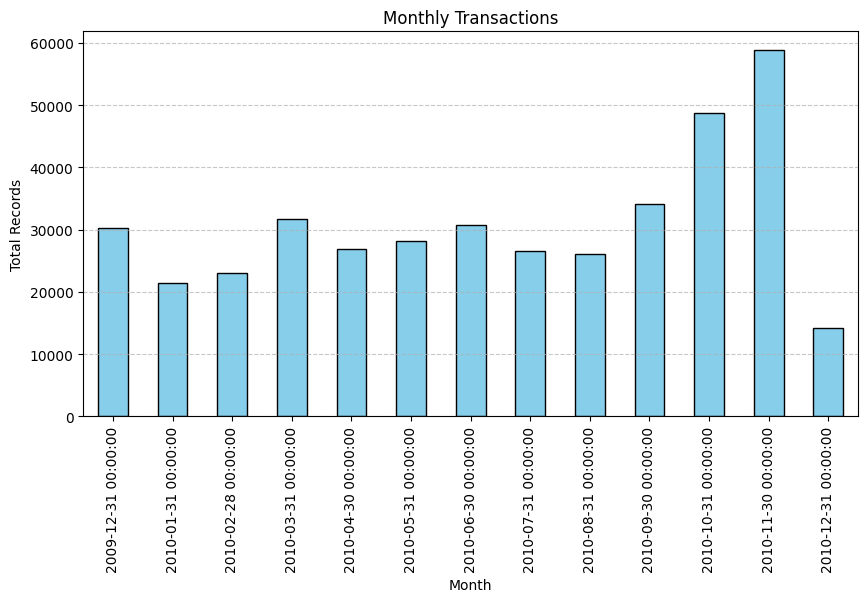

In [46]:
import matplotlib.pyplot as plt

ax = monthly_transactions.plot(
    kind="bar", 
    figsize=(10, 5), 
    color="skyblue", 
    edgecolor="black"
)
plt.title("Monthly Transactions")
plt.xlabel("Month")
plt.ylabel("Total Records")
plt.grid(axis="y", linestyle="--", alpha=0.7)
#plt.tight_layout()
plt.show()

In [50]:
df_clean.to_csv("df_clean.csv", index=False)